In [1]:
import os
import librosa
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.manifold import TSNE

Extracting Log-Mel Spectrograms...
Similarity (Dog vs Dog): 0.9832
Similarity (Dog vs Helicopter): 0.9543


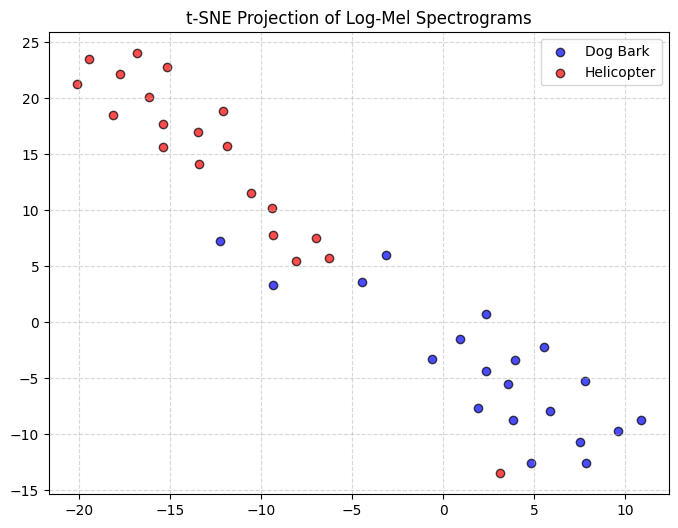

In [2]:

# Load Metadata and filter for two distinct classes (0=Dog, 40=Helicopter)
df = pd.read_csv("../data/raw/ESC-50-master/meta/esc50.csv")
AUDIO_DIR = "../data/raw/ESC-50-master/audio/"
df_subset = pd.concat([df[df['target'] == 0].head(20), df[df['target'] == 40].head(20)])

features, labels = [], []

print("Extracting Log-Mel Spectrograms...")
for _, row in df_subset.iterrows():
    y, sr = librosa.load(os.path.join(AUDIO_DIR, row['filename']), sr=22050)
    mel = librosa.feature.melspectrogram(y=y, sr=sr, n_fft=2048, hop_length=512, n_mels=128)
    log_mel = librosa.power_to_db(mel, ref=np.max)
    features.append(log_mel.flatten())
    labels.append(row['category'])

X = np.array(features)

# Calculate Cosine Similarity
sim_matrix = cosine_similarity(X)
print(f"Similarity (Dog vs Dog): {sim_matrix[0, 1]:.4f}")
print(f"Similarity (Dog vs Helicopter): {sim_matrix[0, 39]:.4f}")

# Run t-SNE
tsne = TSNE(n_components=2, perplexity=10, random_state=42)
X_2d = tsne.fit_transform(X)

# Plot Results
plt.figure(figsize=(8, 6))
plt.scatter(X_2d[:20, 0], X_2d[:20, 1], c='blue', label='Dog Bark', alpha=0.7, edgecolors='k')
plt.scatter(X_2d[20:, 0], X_2d[20:, 1], c='red', label='Helicopter', alpha=0.7, edgecolors='k')
plt.title("t-SNE Projection of Log-Mel Spectrograms")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()